# Introduction

## Purpose

This notebook explores SE3 electricity prices. It looks for useful weather and time patterns.

# Imports

In [71]:
import sys

# Allow the notebook to import modules from the project root.
sys.path.append("..")

from backend.app.ml.preprocessing import prepare_data
import backend.app.ml.preprocessing as preprocessing
import importlib

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Load the raw dataset.
df = pd.read_csv("../dataset/all_zones_complete_2025.csv")

df.head()

,timestamp,temp_se1_c,wind_se1_kmh,rain_se1_mm,temp_se2_c,wind_se2_kmh,rain_se2_mm,temp_se3_c,wind_se3_kmh,rain_se3_mm,temp_se4_c,wind_se4_kmh,rain_se4_mm,price_se1_eur_mwh,price_se2_eur_mwh,price_se3_eur_mwh,price_se4_eur_mwh,timestamp_local
0,2025-01-01 00:00:00+00:00,-9.1,8.6,0.0,-13.1,3.2,0.0,-0.6,18.4,0.0,5.5,43.1,0.9,3.97,3.69,2.47,2.04,2025-01-01 01:00:00+01:00
1,2025-01-01 01:00:00+00:00,-11.6,9.2,0.0,-13.4,5.5,0.0,0.2,12.7,0.0,5.9,43.7,0.3,3.82,3.55,2.44,2.04,2025-01-01 02:00:00+01:00
2,2025-01-01 02:00:00+00:00,-12.2,8.3,0.0,-14.6,6.6,0.0,0.6,5.2,0.1,6.0,42.6,0.7,3.49,3.19,1.98,1.54,2025-01-01 03:00:00+01:00
3,2025-01-01 03:00:00+00:00,-12.5,7.3,0.0,-14.3,7.5,0.0,1.2,6.5,0.1,6.3,44.8,0.9,3.46,3.15,1.79,1.18,2025-01-01 04:00:00+01:00
4,2025-01-01 04:00:00+00:00,-12.6,5.7,0.0,-14.5,8.8,0.0,1.5,7.6,0.1,6.7,48.2,0.7,3.89,3.68,2.71,2.38,2025-01-01 05:00:00+01:00


In [40]:

importlib.reload(preprocessing)

<module 'backend.app.ml.preprocessing' from 'c:\\Users\\cecil\\python\\ai-ml\\Predictor\\backend\\app\\ml\\preprocessing.py'>

In [ ]:
# Apply the project's preprocessing steps and check for missing values.
df_prepared = preprocessing.prepare_data(df)

print(df_prepared.shape)
print(df_prepared["zone"].value_counts())

(35040, 14)
zone
SE1    8760
SE2    8760
SE3    8760
SE4    8760
Name: count, dtype: int64


In [47]:
df_prepared.isna().sum()

timestamp               0
timestamp_local         0
temperature_c           0
wind_speed_kmh          0
rain_mm                 0
spot_price_eur_mwh      0
zone                    0
hour                    0
day_of_week             0
month                   0
is_weekend              0
price_lag_24           96
price_lag_48          192
price_lag_168         672
dtype: int64

In [56]:
df_prepared.columns.tolist()

['timestamp',
 'timestamp_local',
 'temperature_c',
 'wind_speed_kmh',
 'rain_mm',
 'spot_price_eur_mwh',
 'zone',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'price_lag_24',
 'price_lag_48',
 'price_lag_168']

In [57]:
df_prepared.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype                           
---  ------              --------------  -----                           
 0   timestamp           35040 non-null  datetime64[us, UTC]             
 1   timestamp_local     35040 non-null  datetime64[us, Europe/Stockholm]
 2   temperature_c       35040 non-null  float64                         
 3   wind_speed_kmh      35040 non-null  float64                         
 4   rain_mm             35040 non-null  float64                         
 5   spot_price_eur_mwh  35040 non-null  float64                         
 6   zone                35040 non-null  str                             
 7   hour                35040 non-null  int32                           
 8   day_of_week         35040 non-null  int32                           
 9   month               35040 non-null  int32                           
 10  is_weeken

In [58]:
df_prepared[["timestamp", "timestamp_local"]].head()

,timestamp,timestamp_local
0,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+01:00
1,2025-01-01 01:00:00+00:00,2025-01-01 02:00:00+01:00
2,2025-01-01 02:00:00+00:00,2025-01-01 03:00:00+01:00
3,2025-01-01 03:00:00+00:00,2025-01-01 04:00:00+01:00
4,2025-01-01 04:00:00+00:00,2025-01-01 05:00:00+01:00


In [59]:
df_prepared[["timestamp", "timestamp_local"]].dtypes

timestamp                       datetime64[us, UTC]
timestamp_local    datetime64[us, Europe/Stockholm]
dtype: object

In [60]:
print(
    "Chronologically sorted:",
    df["timestamp"].is_monotonic_increasing
)

Chronologically sorted: True


In [61]:
df_prepared.duplicated(
    subset=["zone", "timestamp"]
).sum()

np.int64(0)

In [62]:
df_prepared.groupby("zone")["timestamp"].apply(
    lambda x: x.is_monotonic_increasing
)

zone
SE1    True
SE2    True
SE3    True
SE4    True
Name: timestamp, dtype: bool

In [64]:
time_diff = (
    df_prepared
    .groupby("zone")["timestamp"]
    .diff()
)

time_diff.value_counts()

timestamp
0 days 01:00:00    35036
Name: count, dtype: int64

In [65]:
# Add yesterday's price at the same hour as a forecasting feature.
df_prepared[
    [
        "zone",
        "timestamp_local",
        "spot_price_eur_mwh",
        "price_lag_24"
    ]
].head(30)

,zone,timestamp_local,spot_price_eur_mwh,price_lag_24
0,SE1,2025-01-01 01:00:00+01:00,3.97,NaN
1,SE1,2025-01-01 02:00:00+01:00,3.82,NaN
2,SE1,2025-01-01 03:00:00+01:00,3.49,NaN
3,SE1,2025-01-01 04:00:00+01:00,3.46,NaN
4,SE1,2025-01-01 05:00:00+01:00,3.89,NaN
5,SE1,2025-01-01 06:00:00+01:00,3.54,NaN
6,SE1,2025-01-01 07:00:00+01:00,3.83,NaN
7,SE1,2025-01-01 08:00:00+01:00,4.67,NaN
8,SE1,2025-01-01 09:00:00+01:00,5.15,NaN
9,SE1,2025-01-01 10:00:00+01:00,6.04,NaN


# EDA

In [66]:
df_prepared["spot_price_eur_mwh"].describe()

count    35040.000000
mean        35.037197
std         42.874614
min        -92.880000
25%          4.030000
50%         18.010000
75%         53.630000
max        486.310000
Name: spot_price_eur_mwh, dtype: float64

In [69]:
df_prepared.groupby("zone")["spot_price_eur_mwh"].describe()

,count,mean,std,min,25%,50%,75%,max
zone,,,,,,,,
SE1,8760.0,16.736973,28.313897,-92.88,3.0300,6.040,16.2825,275.19
SE2,8760.0,16.550551,28.656034,-25.22,2.4900,5.135,16.1700,269.26
SE3,8760.0,46.316712,42.941331,-25.05,18.6775,35.670,63.4350,485.72
SE4,8760.0,60.544551,49.316163,-25.30,24.9175,54.850,85.9600,486.31


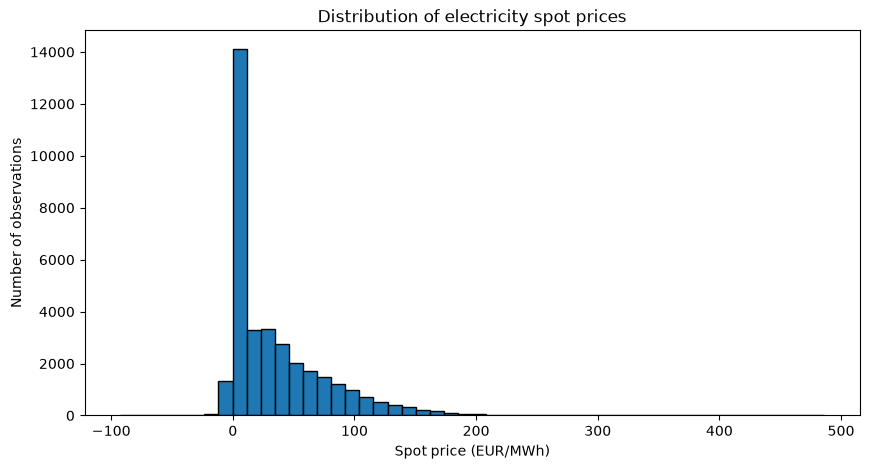

In [68]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_prepared["spot_price_eur_mwh"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Spot price (EUR/MWh)")
plt.ylabel("Number of observations")
plt.title("Distribution of electricity spot prices")

plt.show()

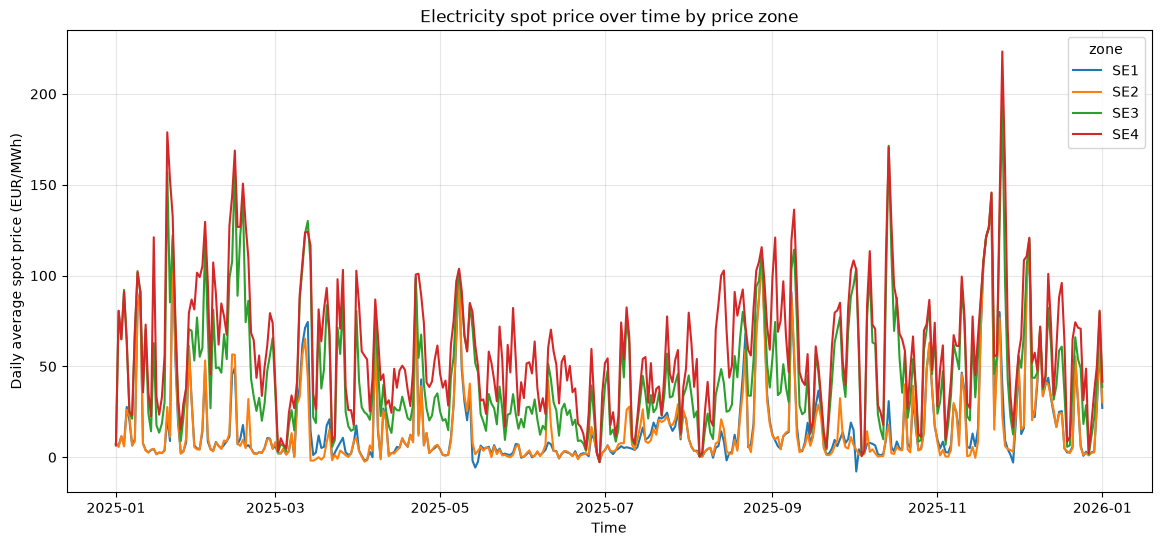

In [85]:
# Calculate daily average electricity price for each price zone.
daily_prices = (
    df_prepared
    .set_index("timestamp_local")
    .groupby("zone")["spot_price_eur_mwh"]
    .resample("D")
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_prices,
    x="timestamp_local",
    y="spot_price_eur_mwh",
    hue="zone"
)

plt.xlabel("Time")
plt.ylabel("Daily average spot price (EUR/MWh)")
plt.title("Electricity spot price over time by price zone")
plt.grid(alpha=0.3)
plt.show()

In [73]:
print("Negative prices:", (df_prepared["spot_price_eur_mwh"] < 0).sum())
print("Zero prices:", (df_prepared["spot_price_eur_mwh"] == 0).sum())
print("Prices above 100 EUR/MWh:", (df_prepared["spot_price_eur_mwh"] > 100).sum())
print("Prices above 200 EUR/MWh:", (df_prepared["spot_price_eur_mwh"] > 200).sum())

Negative prices: 1899
Zero prices: 137
Prices above 100 EUR/MWh: 3045
Prices above 200 EUR/MWh: 209


In [74]:
price_extremes = df_prepared.groupby("zone")["spot_price_eur_mwh"].agg(
    negative=lambda x: (x < 0).sum(),
    zero=lambda x: (x == 0).sum(),
    above_100=lambda x: (x > 100).sum(),
    above_200=lambda x: (x > 200).sum()
)

price_extremes

,negative,zero,above_100,above_200
zone,,,,
SE1,517,35,256,9
SE2,666,66,254,9
SE3,345,23,971,69
SE4,371,13,1564,122


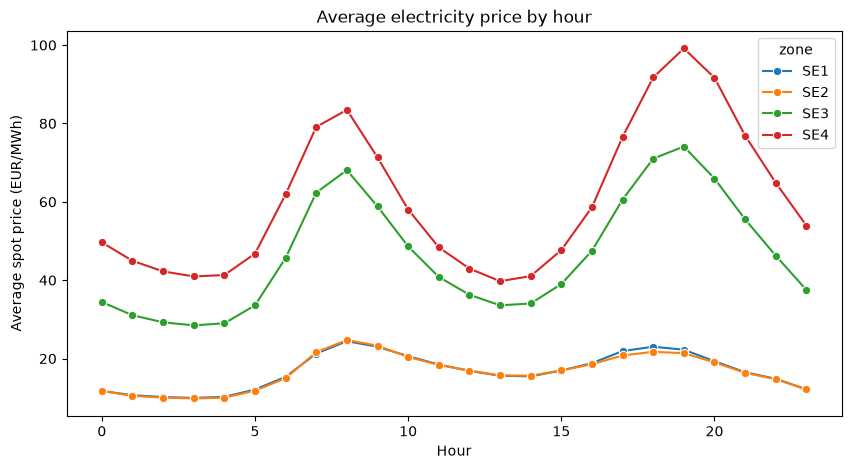

In [75]:
hourly_price = (
    df_prepared
    .groupby(["hour", "zone"])["spot_price_eur_mwh"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_price,
    x="hour",
    y="spot_price_eur_mwh",
    hue="zone",
    marker="o"
)

plt.xlabel("Hour")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by hour")
plt.show()

In [76]:
df_prepared.groupby("zone")["spot_price_eur_mwh"].describe()

,count,mean,std,min,25%,50%,75%,max
zone,,,,,,,,
SE1,8760.0,16.736973,28.313897,-92.88,3.0300,6.040,16.2825,275.19
SE2,8760.0,16.550551,28.656034,-25.22,2.4900,5.135,16.1700,269.26
SE3,8760.0,46.316712,42.941331,-25.05,18.6775,35.670,63.4350,485.72
SE4,8760.0,60.544551,49.316163,-25.30,24.9175,54.850,85.9600,486.31


### Initial observations

Prices range from -25.05 to 393.38 EUR/MWh. The mean price is higher than the median, which suggests that occasional high prices pull the distribution to the right.

Negative prices and price spikes are kept because they are important for forecasting.

In [77]:
weather_features = [
    "temperature_c",
    "wind_speed_kmh",
    "rain_mm"
]

df_prepared[weather_features].describe()

,temperature_c,wind_speed_kmh,rain_mm
count,35040.000000,35040.000000,35040.000000
mean,7.345459,13.433747,0.065822
std,8.365539,7.059295,0.371415
min,-23.700000,0.000000,0.000000
25%,1.800000,8.200000,0.000000
50%,7.400000,12.600000,0.000000
75%,13.600000,17.800000,0.000000
max,30.400000,52.900000,22.900000


In [78]:
# Measure linear relationships between weather variables and electricity price.
correlations = df_prepared[
    [
        "temperature_c",
        "wind_speed_kmh",
        "rain_mm",
        "spot_price_eur_mwh"
    ]
].corr()

correlations

,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh
temperature_c,1.000000,0.064498,0.085090,-0.105563
wind_speed_kmh,0.064498,1.000000,0.072763,-0.170482
rain_mm,0.085090,0.072763,1.000000,-0.049903
spot_price_eur_mwh,-0.105563,-0.170482,-0.049903,1.000000


In [23]:
correlations["spot_price_eur_mwh"].sort_values(
    ascending=False
)

spot_price_eur_mwh    1.000000
rain_mm              -0.047681
wind_speed_kmh       -0.283828
temperature_c        -0.443439
Name: spot_price_eur_mwh, dtype: float64

### Correlation observations

Higher temperatures and stronger wind are generally linked to lower prices. Rain has almost no linear relationship with price.

Correlation does not show cause and effect. These features may still help a Random Forest model.

In [79]:
# Check the time-based features created during preprocessing.
df_prepared[
    ["timestamp_local", "hour", "day_of_week", "month", "is_weekend"]
].head()

,timestamp_local,hour,day_of_week,month,is_weekend
0,2025-01-01 01:00:00+01:00,1,2,1,0
1,2025-01-01 02:00:00+01:00,2,2,1,0
2,2025-01-01 03:00:00+01:00,3,2,1,0
3,2025-01-01 04:00:00+01:00,4,2,1,0
4,2025-01-01 05:00:00+01:00,5,2,1,0


In [80]:
# Calculate average hourly electricity prices for each price zone.
hourly_prices = (
    df_prepared
    .groupby(["zone", "hour"])["spot_price_eur_mwh"]
    .mean()
    .reset_index()
)

hourly_prices

,zone,hour,spot_price_eur_mwh
0,SE1,0,11.743507
1,SE1,1,10.646603
2,SE1,2,10.172521
3,SE1,3,9.952959
4,SE1,4,10.235973
...,...,...,...
91,SE4,19,99.144384
92,SE4,20,91.654274
93,SE4,21,76.900219
94,SE4,22,64.849151


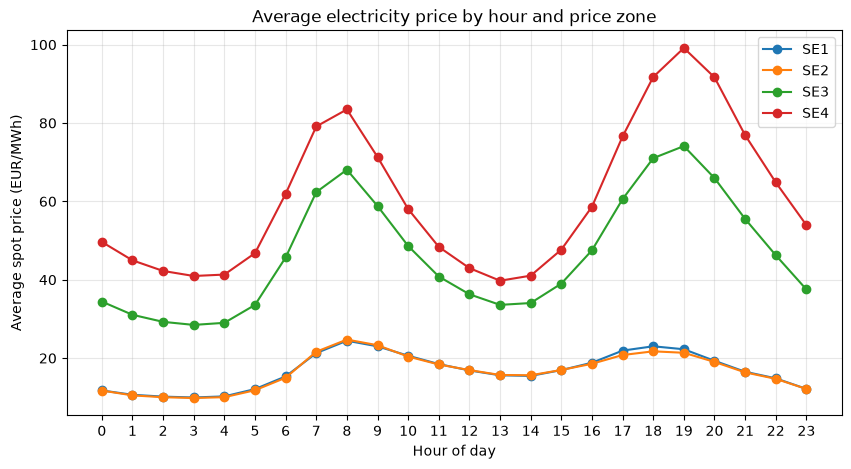

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for zone in hourly_prices["zone"].unique():
    zone_data = hourly_prices[hourly_prices["zone"] == zone]

    plt.plot(
        zone_data["hour"],
        zone_data["spot_price_eur_mwh"],
        marker="o",
        label=zone
    )

plt.xticks(range(24))

plt.xlabel("Hour of day")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by hour and price zone")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [82]:
# Calculate average electricity prices by weekday for each price zone.
weekday_prices = (
    df_prepared
    .groupby(["zone", "day_of_week"])["spot_price_eur_mwh"]
    .mean()
    .reset_index()
)

weekday_prices

,zone,day_of_week,spot_price_eur_mwh
0,SE1,0,19.701362
1,SE1,1,20.130425
2,SE1,2,19.440559
3,SE1,3,22.418279
4,SE1,4,19.309631
5,SE1,5,7.335929
6,SE1,6,8.768245
7,SE2,0,19.436314
8,SE2,1,19.995689
9,SE2,2,19.745625


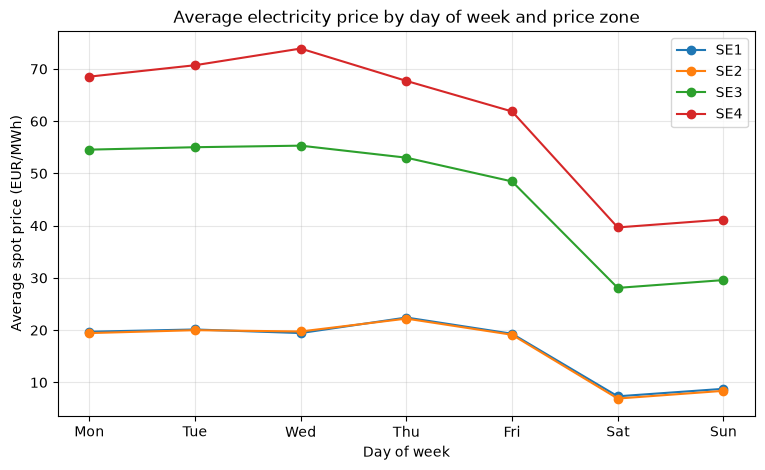

In [83]:
weekday_names = [
    "Mon", "Tue", "Wed", "Thu",
    "Fri", "Sat", "Sun"
]

plt.figure(figsize=(9, 5))

for zone in weekday_prices["zone"].unique():
    zone_data = weekday_prices[weekday_prices["zone"] == zone]

    plt.plot(
        zone_data["day_of_week"],
        zone_data["spot_price_eur_mwh"],
        marker="o",
        label=zone
    )

plt.xticks(
    range(7),
    weekday_names
)

plt.xlabel("Day of week")
plt.ylabel("Average spot price (EUR/MWh)")
plt.title("Average electricity price by day of week and price zone")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Time-based patterns

Prices are usually lowest at night and in the early afternoon. They often peak in the morning and evening.

Weekend prices are lower than weekday prices. Hour, day of week, and weekend status may help the model.

In [84]:
# Summarize monthly electricity prices for each price zone.
monthly_prices = (
    df_prepared
    .groupby(["zone", "month"])["spot_price_eur_mwh"]
    .agg(["mean", "median", "std", "count"])
    .reset_index()
)

monthly_prices

,zone,month,mean,median,std,count
0,SE1,1,20.715833,6.890,34.922176,744
1,SE1,2,11.382158,6.330,17.253112,672
2,SE1,3,14.401104,4.830,23.847698,743
3,SE1,4,13.078056,4.670,29.770576,720
4,SE1,5,12.909073,4.215,25.588993,744
5,SE1,6,2.770167,2.275,5.137218,720
6,SE1,7,12.135309,8.770,10.079061,744
7,SE1,8,21.315860,5.990,33.703564,744
8,SE1,9,15.718264,8.535,25.348082,720
9,SE1,10,12.957315,5.470,18.772671,745
